# 03 — Alerta de estrés y conclusiones

Evaluación del ranking de estrés a seis meses. Se distingue entre
capacidad de ordenar casos y calibración probabilística, porque una
buena Average Precision no garantiza probabilidades confiables.

In [1]:
from pathlib import Path

ROOT = Path.cwd().resolve()
if ROOT.name.lower() == "notebooks":
    ROOT = ROOT.parent

print(f"Raíz del proyecto: {ROOT}")

Raíz del proyecto: C:\Users\litoa\OneDrive\Documents\GitHub\ml_finance_carenas\Morosidad_bancaria_arenas


In [2]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

stress = pd.read_csv(ROOT / "reports" / "tables" / "stress_alert_metrics_development.csv")
overall = stress.loc[stress["fold_id"].astype(str) == "all"].copy()
overall[["model", "events", "average_precision", "roc_auc", "brier_score", "precision", "recall"]]

,model,events,average_precision,roc_auc,brier_score,precision,recall
16,historical_prevalence,16,0.339129,0.475000,0.248204,0.000000,0.0000
17,logistic_regression,16,0.771382,0.787500,0.276900,0.600000,0.5625
18,random_forest,16,0.465693,0.672917,0.254168,0.410256,1.0000
19,xgboost,16,0.459925,0.641667,0.298846,0.480000,0.7500


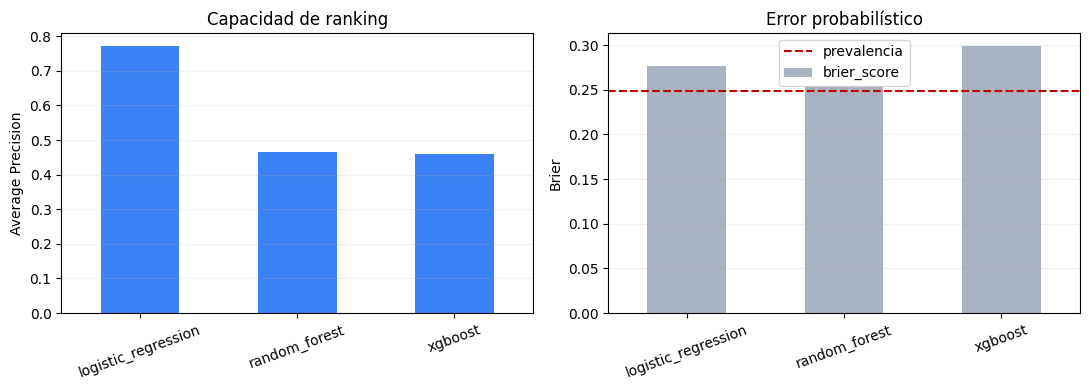

In [3]:
candidates = overall.loc[overall["model"] != "historical_prevalence"].copy()
best = candidates.sort_values("average_precision", ascending=False).iloc[0]
prevalence = overall.loc[overall["model"] == "historical_prevalence"].iloc[0]

figure, axes = plt.subplots(1, 2, figsize=(11, 4))
candidates.plot.bar(x="model", y="average_precision", ax=axes[0], color="#3b82f6", legend=False)
candidates.plot.bar(x="model", y="brier_score", ax=axes[1], color="#a8b2c1", legend=False)
axes[1].axhline(prevalence["brier_score"], color="#c00000", linestyle="--", label="prevalencia")
axes[0].set(title="Capacidad de ranking", ylabel="Average Precision", xlabel="")
axes[1].set(title="Error probabilístico", ylabel="Brier", xlabel="")
axes[1].legend()
for axis in axes:
    axis.tick_params(axis="x", rotation=20)
    axis.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

## Controles técnicos y decisión

In [4]:
acceptance = json.loads(
    (ROOT / "data" / "metadata" / "technical_acceptance_v001.json").read_text(encoding="utf-8")
)
calibrated = float(best["brier_score"]) <= float(prevalence["brier_score"])
holdout = next(
    check["observed"] for check in acceptance["checks"]
    if check["id"] == "holdout_rows_evaluated"
)

display(Markdown(f'''            - Mejor ranking de estrés: **{best['model']}**, AP **{best['average_precision']:.3f}**.
- Brier del challenger: **{best['brier_score']:.3f}**; prevalencia: **{prevalence['brier_score']:.3f}**.
- ¿Probabilidad mejor calibrada que prevalencia?: **{'sí' if calibrated else 'no'}**.
- Estado técnico: **{acceptance['status']} ({acceptance['checks_passed']}/{acceptance['checks_total']})**.
- Filas de holdout evaluadas: **{holdout}**.
'''))

            - Mejor ranking de estrés: **logistic_regression**, AP **0.771**.
- Brier del challenger: **0.277**; prevalencia: **0.248**.
- ¿Probabilidad mejor calibrada que prevalencia?: **no**.
- Estado técnico: **passed (11/11)**.
- Filas de holdout evaluadas: **0**.


In [5]:
comparison_path = ROOT / "reports" / "reproduction_comparison.json"
if comparison_path.exists():
    comparison = json.loads(comparison_path.read_text(encoding="utf-8"))
    verdict = "NO CAMBIARON" if not comparison["conclusions_changed"] else "CAMBIARON"
    display(Markdown(
        f"## Veredicto de reproducción\n\n"
        f"Las conclusiones **{verdict}**. "
        f"Archivos analíticos clave con diferencias: **{comparison['key_files_changed']}**."
    ))

## Veredicto de reproducción

Las conclusiones **NO CAMBIARON**. Archivos analíticos clave con diferencias: **0**.

## Conclusión final

El modelo simple gana por evidencia, no por defecto. Cambio cero se
mantiene como campeón h=6; ElasticNet queda como challenger de
investigación. La logística sirve para priorizar episodios, pero no
como probabilidad calibrada ni alerta operativa. El holdout continúa
cerrado.